# 📊 Notebook 3 — EDA & Visualizations
**Project:** AI-Driven Citizen Grievance Analysis  
**Input:**  `data/processed/grievance_processed.csv` ← from Notebook 2  
**Output:** All plots saved to `outputs/` folder

### What this notebook does:
- Bar charts: complaint types, boroughs, hourly patterns
- Resolution time analysis
- Class imbalance check (important for Macro F1)
- Borough × Complaint heatmap
- Word Clouds (overall + per category)
- N-gram frequency charts (unigrams, bigrams, trigrams)
- Saves all plots as PNG files to `outputs/`

---

## Import Libraries & Setup Paths

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from nltk.util import ngrams
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ── Folder Paths (relative to notebooks/ folder) ─────────────────────────────
INPUT_FILE  = '../data/processed/grievance_processed.csv'
OUTPUT_DIR  = '../outputs/'

# Helper: save plots to outputs folder
def save_plot(filename):
    path = OUTPUT_DIR + filename
    plt.savefig(path, bbox_inches='tight')
    print(f'💾 Saved → {path}')

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('✅ Libraries ready!')
print(f'📂 Reading from : {INPUT_FILE}')
print(f'📂 Plots saved to: {OUTPUT_DIR}')

✅ Libraries ready!
📂 Reading from : ../data/processed/grievance_processed.csv
📂 Plots saved to: ../outputs/


## Load Preprocessed Data from Notebook 2

In [2]:
df = pd.read_csv(INPUT_FILE)

print(f'Loaded {len(df):,} rows, {df.shape[1]} columns')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Loaded 24,774 rows, 21 columns
Columns: ['Unique Key', 'Created Date', 'Closed Date', 'Agency Name', 'Complaint Type', 'Descriptor', 'Location Type', 'Borough', 'Status', 'Resolution Description', 'is_complaint', 'resolution_hours', 'hour_created', 'day_of_week', 'closed_date_fmt', 'resolution_hours_fmt', 'hour_created_fmt', 'combined_text', 'clean_text', 'token_count', 'unique_tokens']


,Unique Key,Created Date,Closed Date,Agency Name,Complaint Type,Descriptor,Location Type,Borough,Status,Resolution Description,...,resolution_hours,hour_created,day_of_week,closed_date_fmt,resolution_hours_fmt,hour_created_fmt,combined_text,clean_text,token_count,unique_tokens
0,32274996,2015-12-26 23:03:56,2015-12-27 01:27:37,New York City Police Department,Public Notice,Area Information,Street/Sidewalk,QUEENS,Closed,No violations or issues detected.,...,2.394722,23,Saturday,2015-12-27 01:27:37,2.4 hrs,11 PM,Public Notice Area Information No violations o...,public notice area violation issue,5,5
1,32252575,2015-12-22 19:43:42,2015-12-22 21:31:10,New York City Police Department,Information Request,Area Information,Street/Sidewalk,BROOKLYN,Closed,The situation is under control and satisfactory.,...,1.791111,19,Tuesday,2015-12-22 21:31:10,1.8 hrs,07 PM,Information Request Area Information The situa...,area situation control satisfactory,4,4
2,31768878,2015-10-16 22:42:12,NaN,New York City Police Department,Status Check,Community Update,Street/Sidewalk,Unspecified,Assigned,Everything appears to be in good order.,...,NaN,22,Friday,In Progress,In Progress,10 PM,Status Check Community Update Everything appea...,community update everything appears good order,6,6


---
# 📊 SECTION A — EDA Charts

## Top 15 Complaint Types (Bar Chart)

💾 Saved → ../outputs/plot_01_complaint_types.png


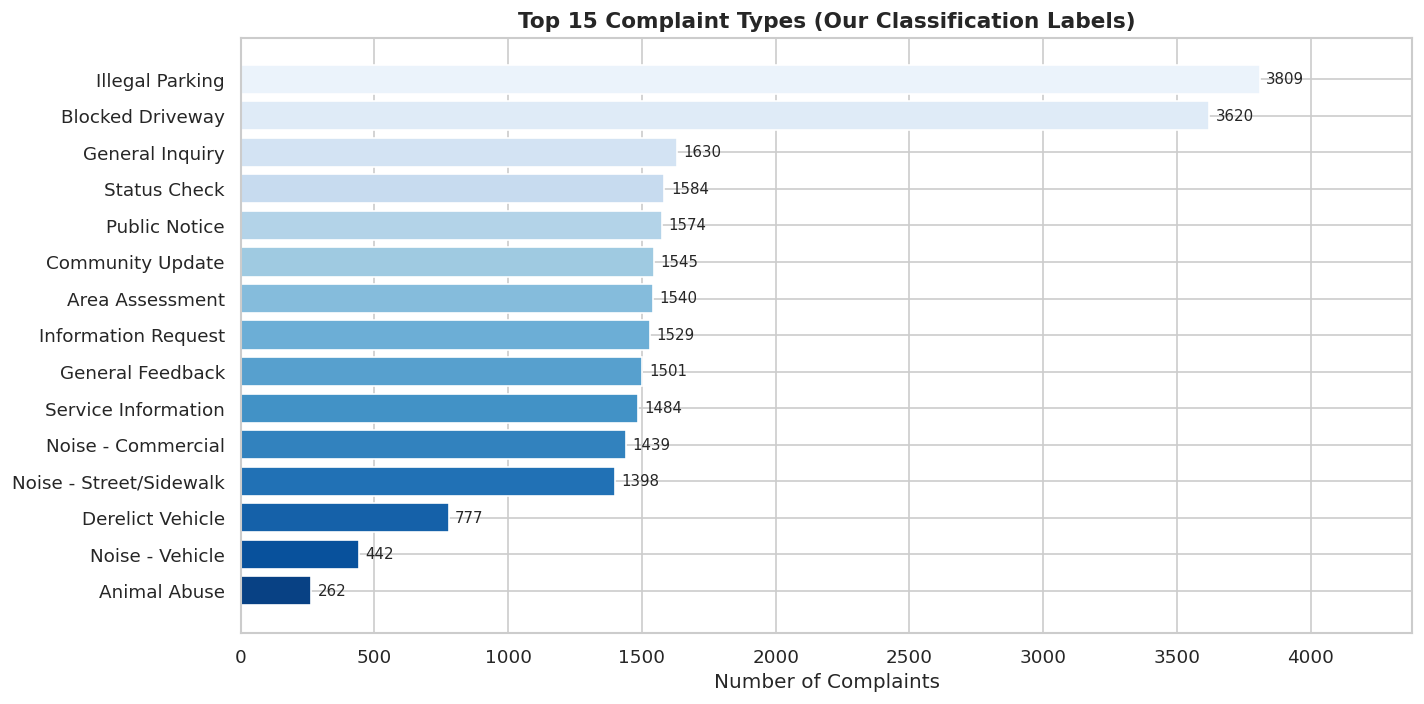


Value counts:
Complaint Type
Illegal Parking            3809
Blocked Driveway           3620
General Inquiry            1630
Status Check               1584
Public Notice              1574
Community Update           1545
Area Assessment            1540
Information Request        1529
General Feedback           1501
Service Information        1484
Noise - Commercial         1439
Noise - Street/Sidewalk    1398
Derelict Vehicle            777
Noise - Vehicle             442
Animal Abuse                262
Name: count, dtype: int64


In [3]:
top_complaints = df['Complaint Type'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    top_complaints.index[::-1],
    top_complaints.values[::-1],
    color=sns.color_palette('Blues_r', 15)
)
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_title('Top 15 Complaint Types (Our Classification Labels)', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Complaints')
ax.set_xlim(0, top_complaints.max() * 1.15)
plt.tight_layout()
save_plot('plot_01_complaint_types.png')
plt.show()

print('\nValue counts:')
print(top_complaints)

##  Class Imbalance Pie Chart
⚠️ This shows why we need **Macro F1** — some classes are very small.

💾 Saved → ../outputs/plot_02_class_imbalance.png


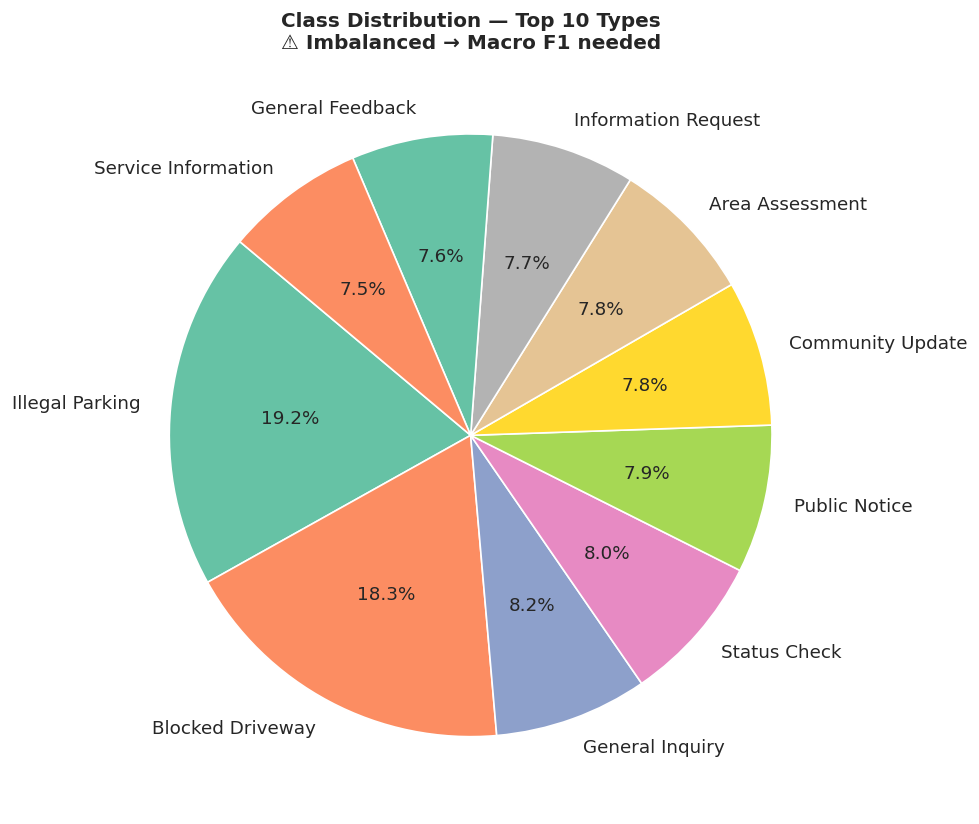

In [4]:
complaint_pct = df['Complaint Type'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 7))
complaint_pct.plot.pie(
    ax=ax,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set2', 10)
)
ax.set_ylabel('')
ax.set_title(
    'Class Distribution — Top 10 Types\n⚠️ Imbalanced → Macro F1 needed',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
save_plot('plot_02_class_imbalance.png')
plt.show()

## Complaints by Borough

💾 Saved → ../outputs/plot_03_borough.png


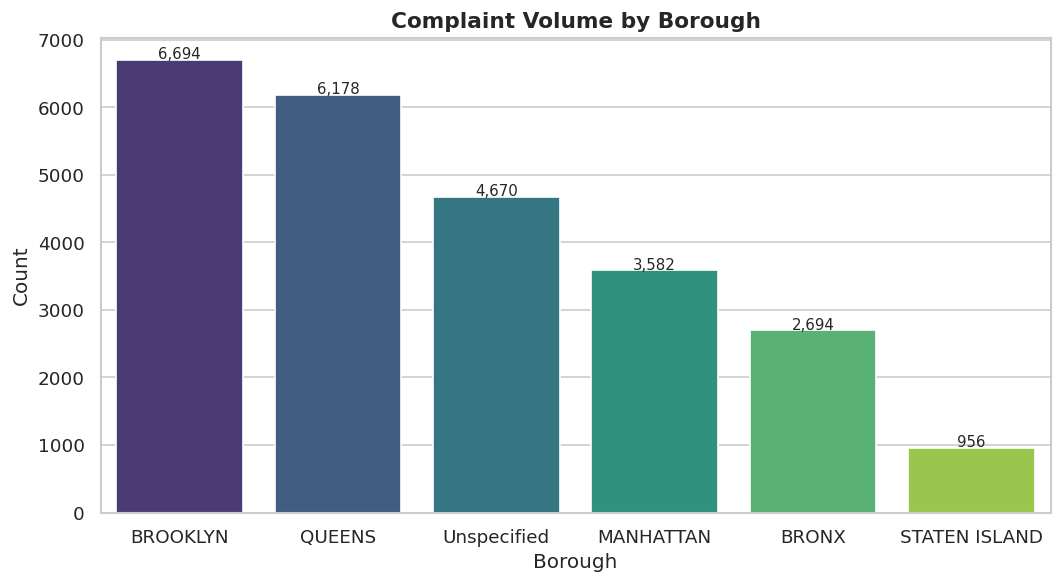

In [5]:
borough_counts = df['Borough'].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=borough_counts.index, y=borough_counts.values,
            palette='viridis', ax=ax)

# Add count labels on top of each bar
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f'{int(bar.get_height()):,}',
        ha='center', fontsize=9
    )

ax.set_title('Complaint Volume by Borough', fontsize=13, fontweight='bold')
ax.set_xlabel('Borough')
ax.set_ylabel('Count')
plt.tight_layout()
save_plot('plot_03_borough.png')
plt.show()

## Complaints by Hour of Day

💾 Saved → ../outputs/plot_04_hourly.png


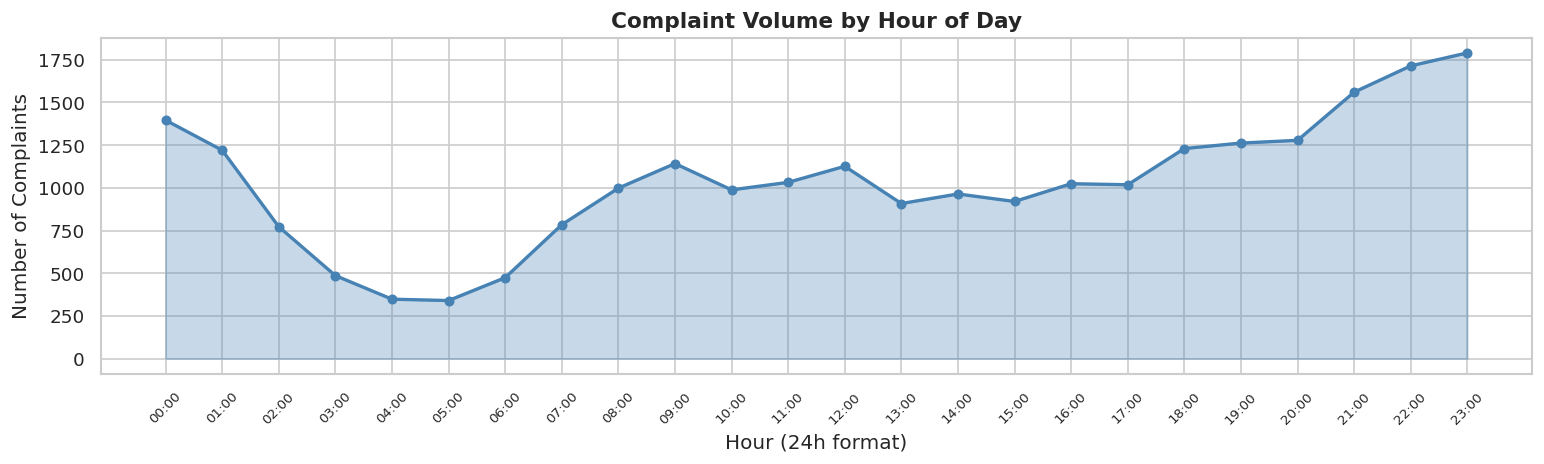

In [6]:
hourly = df.groupby('hour_created').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(hourly['hour_created'], hourly['count'], alpha=0.3, color='steelblue')
ax.plot(hourly['hour_created'], hourly['count'],
        color='steelblue', linewidth=2, marker='o', markersize=5)

ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, fontsize=8)
ax.set_title('Complaint Volume by Hour of Day', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour (24h format)')
ax.set_ylabel('Number of Complaints')
plt.tight_layout()
save_plot('plot_04_hourly.png')
plt.show()

## Resolution Time Analysis

💾 Saved → ../outputs/plot_05_resolution_time.png


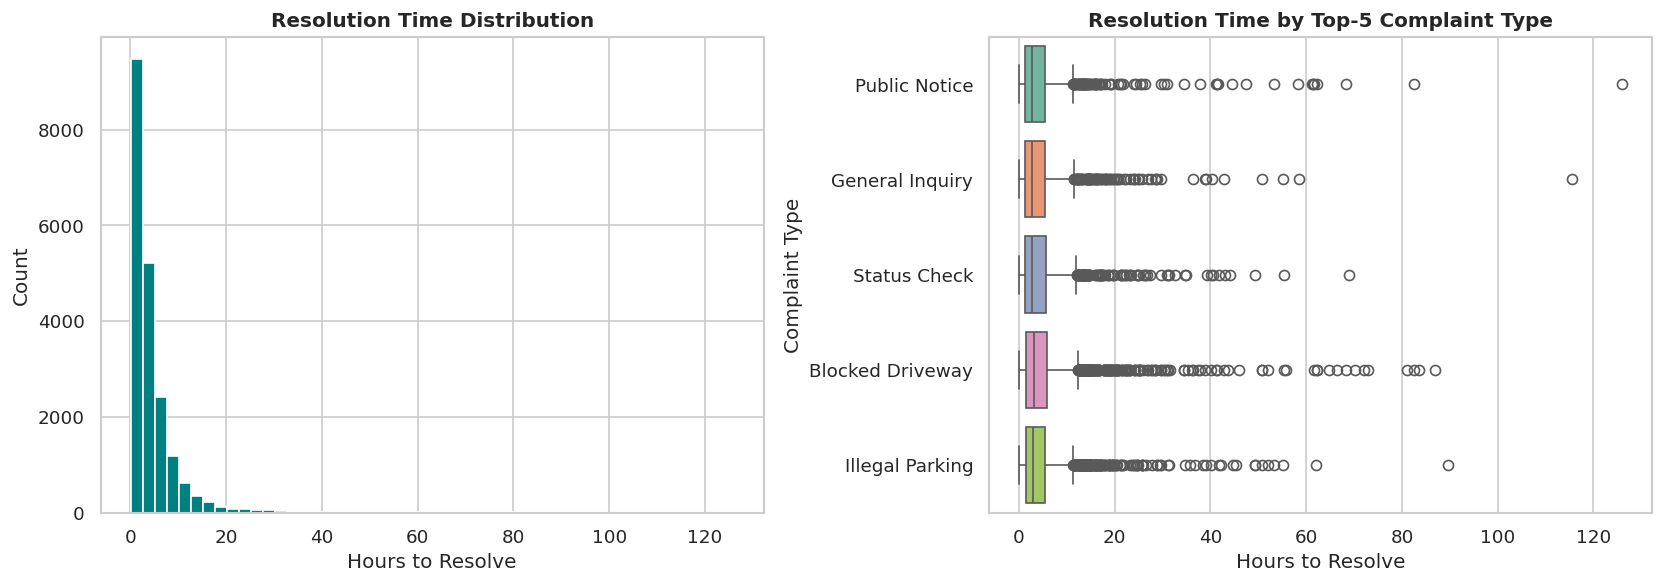

In [7]:
# Filter outliers (keep 0 to 200 hours)
res = df['resolution_hours'].dropna()
res = res[(res >= 0) & (res < 200)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT — Overall histogram
axes[0].hist(res, bins=50, color='teal', edgecolor='white')
axes[0].set_title('Resolution Time Distribution', fontweight='bold')
axes[0].set_xlabel('Hours to Resolve')
axes[0].set_ylabel('Count')

# RIGHT — Boxplot per top-5 complaint type
top5 = df['Complaint Type'].value_counts().head(5).index
df_top5 = df[
    df['Complaint Type'].isin(top5) &
    (df['resolution_hours'] >= 0) &
    (df['resolution_hours'] < 200)
]
sns.boxplot(data=df_top5, y='Complaint Type', x='resolution_hours',
            palette='Set2', ax=axes[1])
axes[1].set_title('Resolution Time by Top-5 Complaint Type', fontweight='bold')
axes[1].set_xlabel('Hours to Resolve')

plt.tight_layout()
save_plot('plot_05_resolution_time.png')
plt.show()

## Borough × Complaint Type Heatmap

💾 Saved → ../outputs/plot_06_heatmap.png


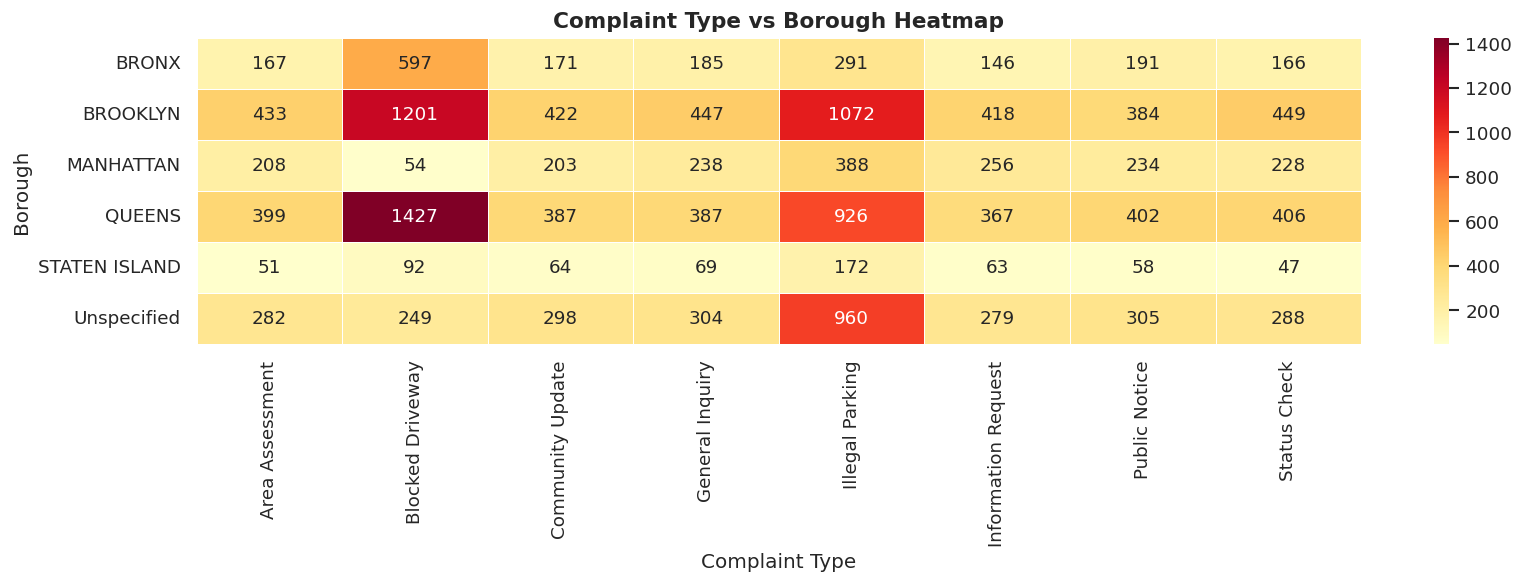

In [8]:
top8 = df['Complaint Type'].value_counts().head(8).index

heatmap_data = (
    df[df['Complaint Type'].isin(top8)]
    .groupby(['Borough', 'Complaint Type'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_data, annot=True, fmt='d',
            cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Complaint Type vs Borough Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
save_plot('plot_06_heatmap.png')
plt.show()

---
# ☁️ SECTION B — Word Clouds

##  Word Cloud: All Complaints Combined

💾 Saved → ../outputs/wordcloud_01_all.png


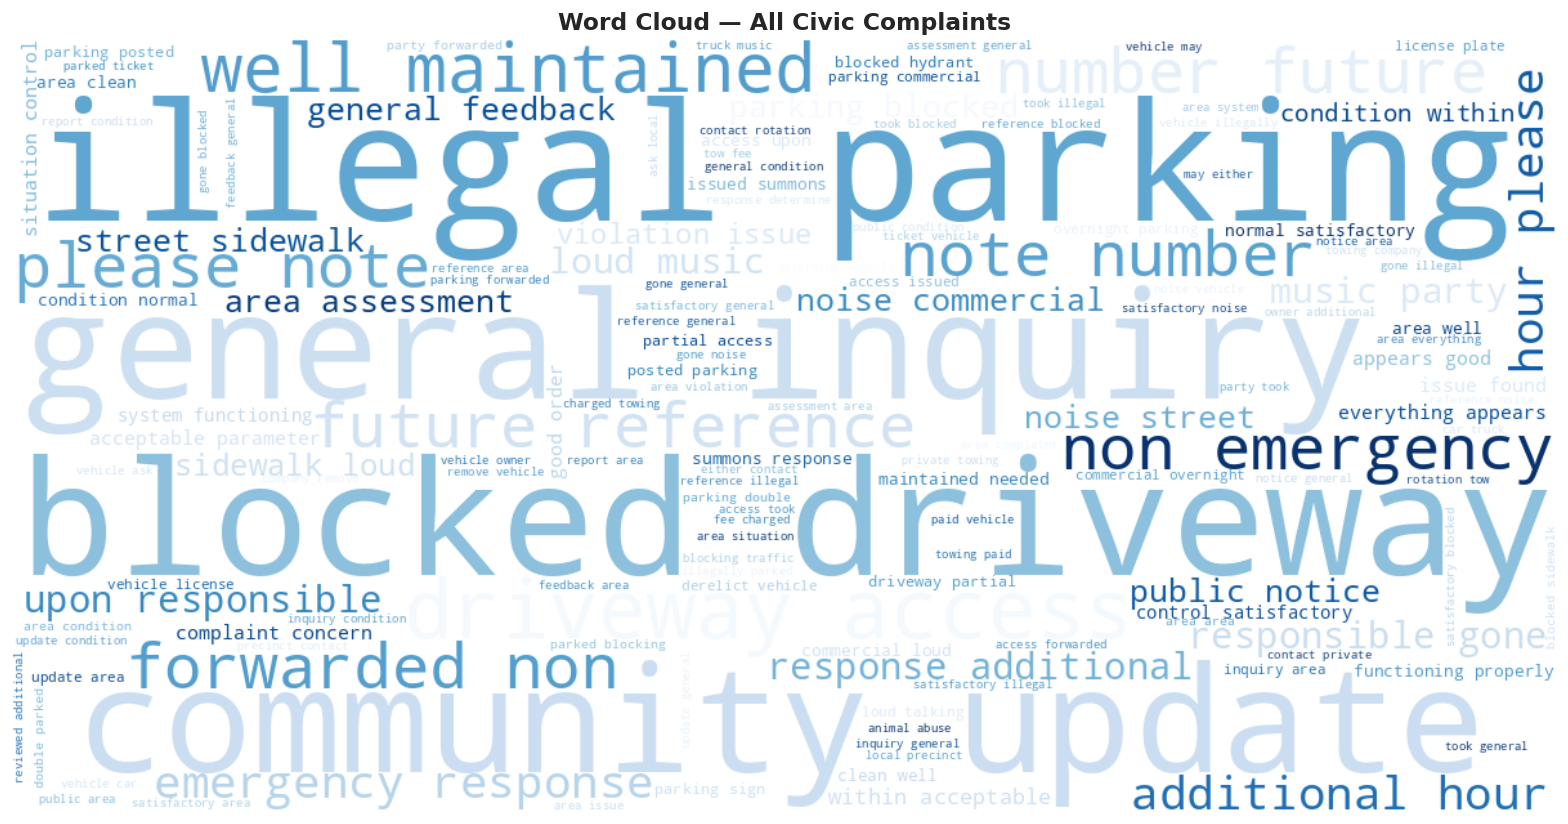

In [9]:
all_text = ' '.join(df['clean_text'].dropna().tolist())

wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    colormap='Blues',
    max_words=150
).generate(all_text)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — All Civic Complaints', fontsize=14, fontweight='bold')
plt.tight_layout()
save_plot('wordcloud_01_all.png')
plt.show()

## Word Clouds: One per Top-6 Complaint Category

💾 Saved → ../outputs/wordcloud_02_per_category.png


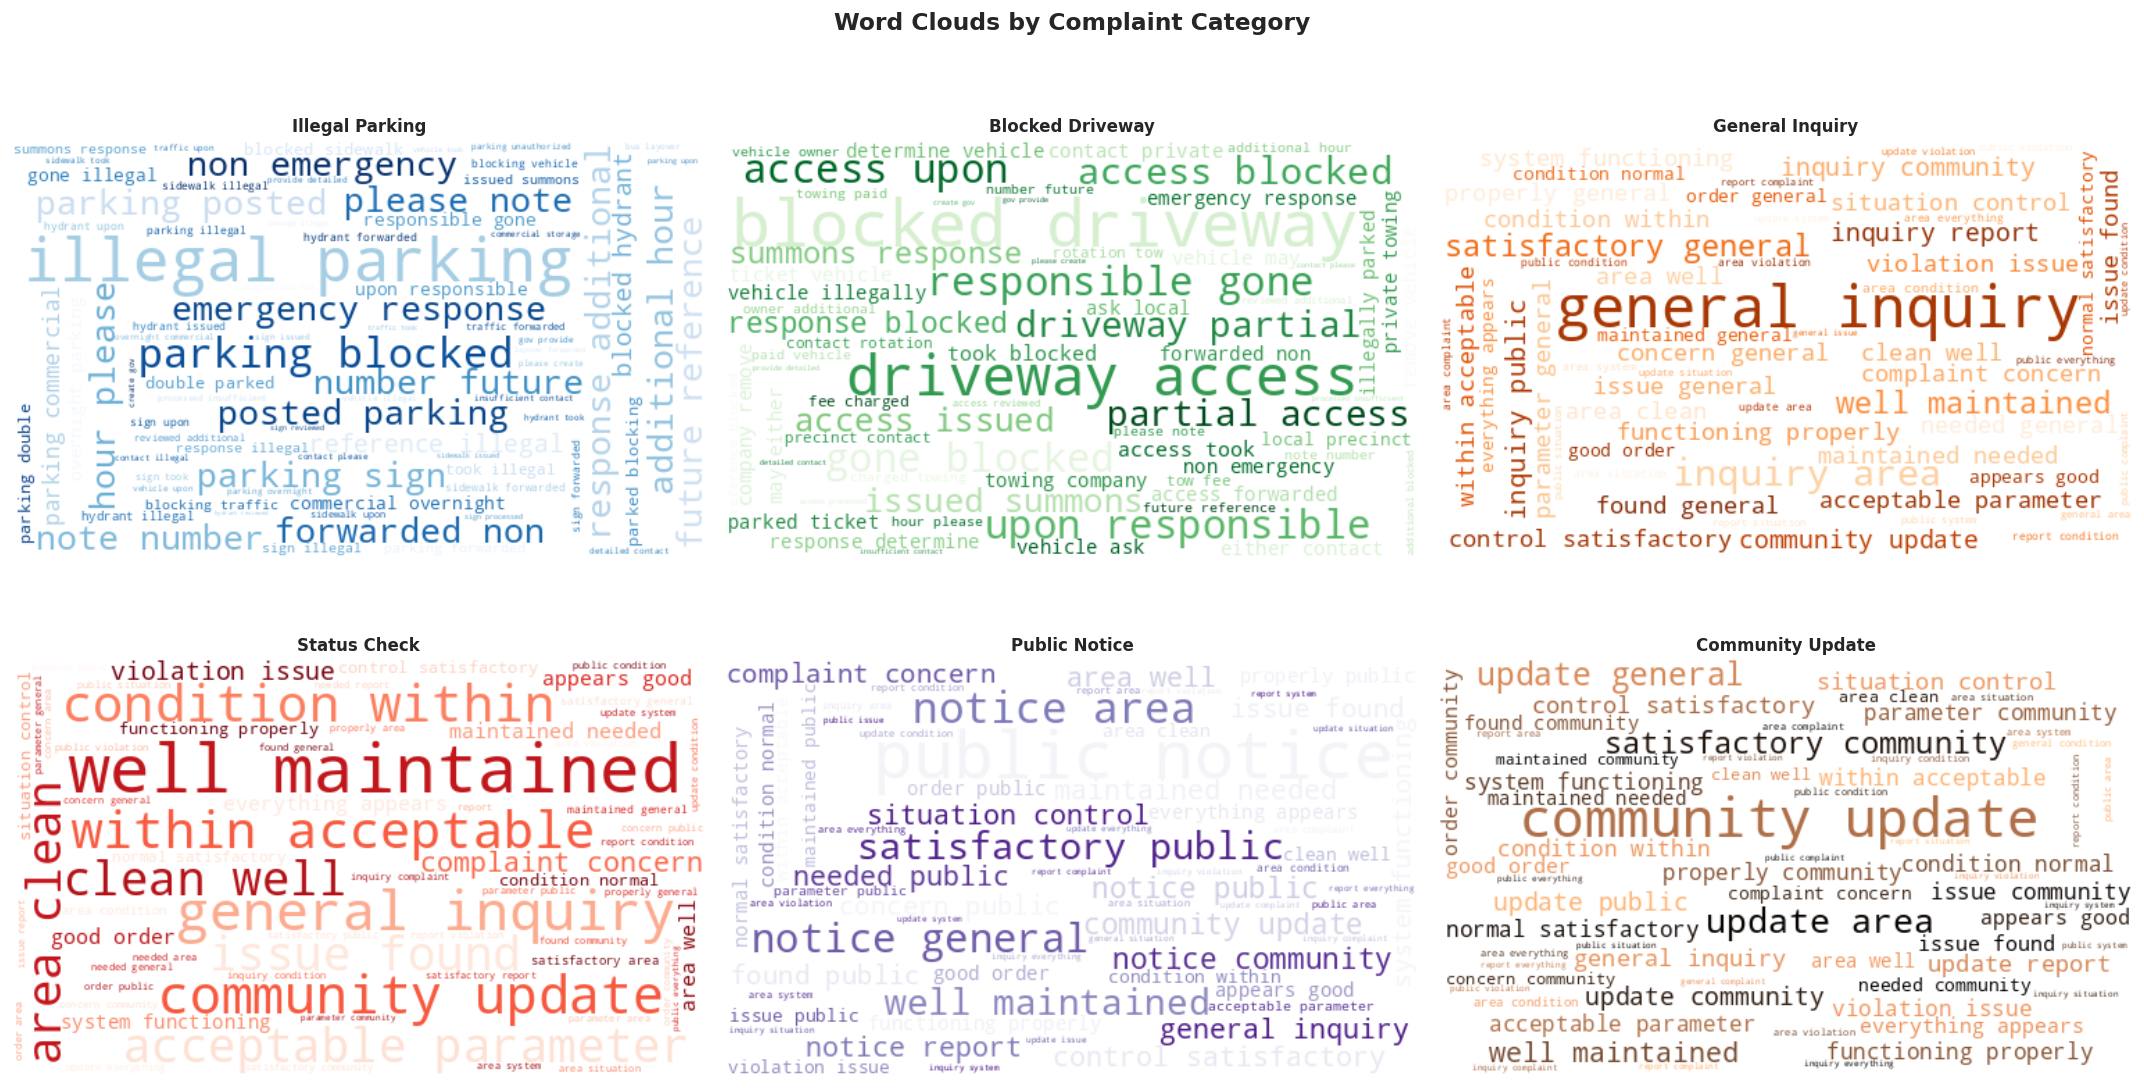

In [10]:
top6      = df['Complaint Type'].value_counts().head(6).index.tolist()
colormaps = ['Blues', 'Greens', 'Oranges', 'Reds', 'Purples', 'copper']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, cat, cmap in zip(axes.flatten(), top6, colormaps):
    cat_text = ' '.join(
        df.loc[df['Complaint Type'] == cat, 'clean_text'].dropna()
    )
    if cat_text.strip():
        wc = WordCloud(
            width=500, height=300,
            background_color='white',
            colormap=cmap,
            max_words=80
        ).generate(cat_text)
        ax.imshow(wc, interpolation='bilinear')
    ax.set_title(cat, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('Word Clouds by Complaint Category', fontsize=14, fontweight='bold')
plt.tight_layout()
save_plot('wordcloud_02_per_category.png')
plt.show()

---
# 📈 SECTION C — N-gram Frequency Analysis

##  Helper Function for N-grams

In [11]:
def get_ngram_freq(corpus, n, top_k=20):
    """
    Given a pandas Series of clean text,
    return a DataFrame of top-k most frequent n-grams.
    """
    all_tokens = [token for doc in corpus.dropna() for token in doc.split()]
    ng         = ngrams(all_tokens, n)
    freq       = Counter(ng).most_common(top_k)
    labels     = [' '.join(gram) for gram, _ in freq]
    counts     = [count for _, count in freq]
    return pd.DataFrame({'ngram': labels, 'count': counts})

print('✅ get_ngram_freq() defined!')

✅ get_ngram_freq() defined!


##  Top 20 Unigrams (single words)

💾 Saved → ../outputs/plot_07_unigrams.png


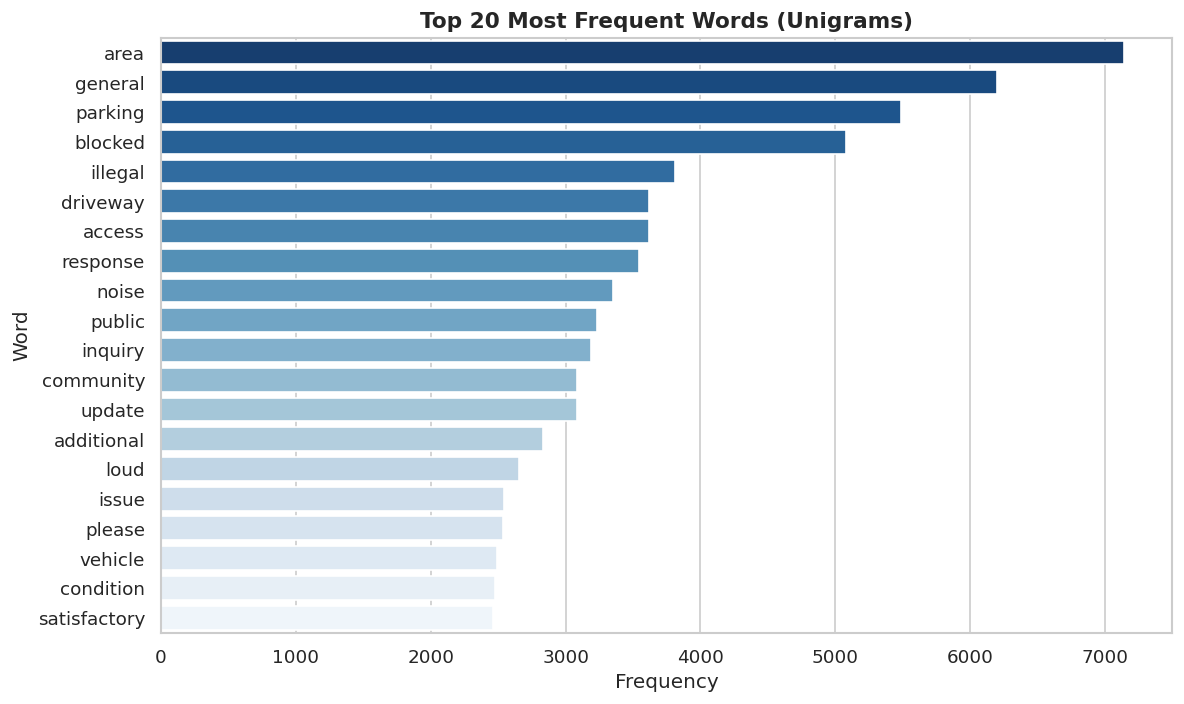

       ngram  count
        area   7141
     general   6195
     parking   5489
     blocked   5082
     illegal   3809
    driveway   3620
      access   3620
    response   3543
       noise   3352
      public   3230
     inquiry   3188
   community   3082
      update   3082
  additional   2830
        loud   2656
       issue   2546
      please   2536
     vehicle   2491
   condition   2476
satisfactory   2460


In [12]:
unigrams = get_ngram_freq(df['clean_text'], n=1, top_k=20)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=unigrams, y='ngram', x='count', palette='Blues_r', ax=ax)
ax.set_title('Top 20 Most Frequent Words (Unigrams)', fontsize=13, fontweight='bold')
ax.set_xlabel('Frequency')
ax.set_ylabel('Word')
plt.tight_layout()
save_plot('plot_07_unigrams.png')
plt.show()

print(unigrams.to_string(index=False))

##  Top 20 Bigrams (two-word phrases)

💾 Saved → ../outputs/plot_08_bigrams.png


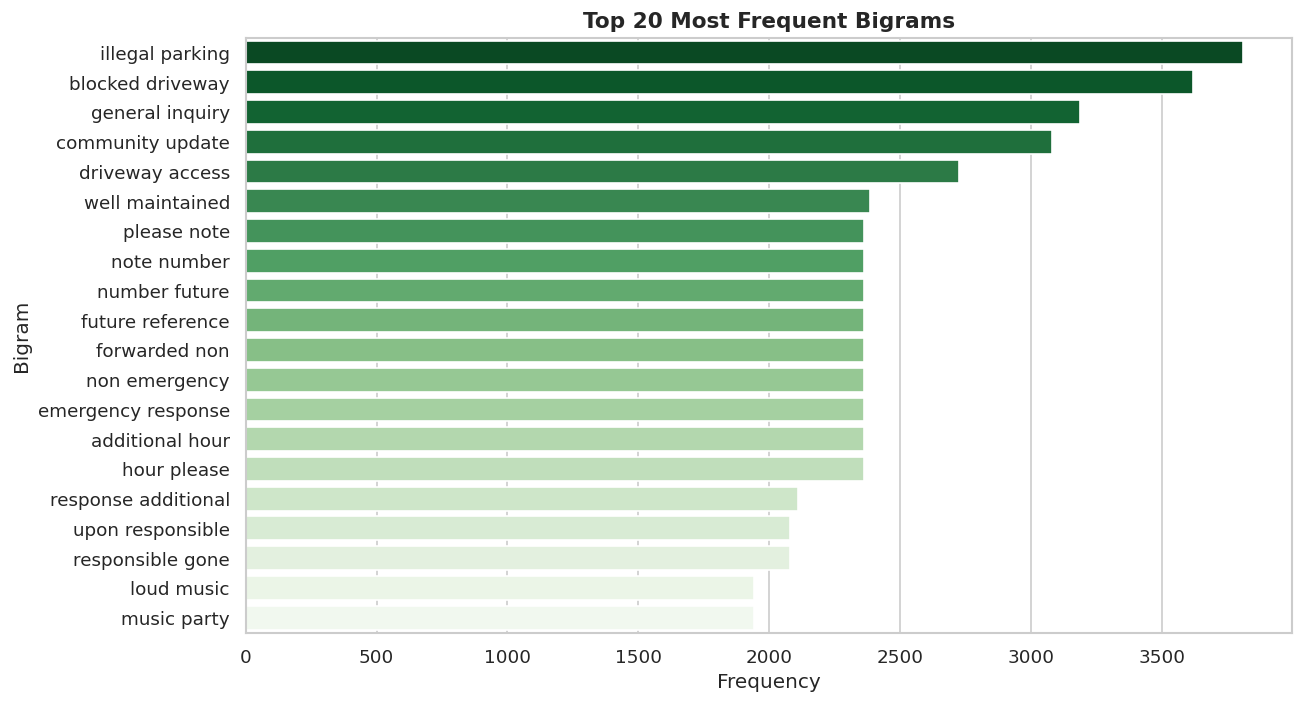

              ngram  count
    illegal parking   3809
   blocked driveway   3620
    general inquiry   3188
   community update   3082
    driveway access   2726
    well maintained   2385
        please note   2363
        note number   2363
      number future   2363
   future reference   2363
      forwarded non   2362
      non emergency   2362
 emergency response   2362
    additional hour   2362
        hour please   2362
response additional   2109
   upon responsible   2080
   responsible gone   2080
         loud music   1944
        music party   1944


In [13]:
bigrams = get_ngram_freq(df['clean_text'], n=2, top_k=20)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=bigrams, y='ngram', x='count', palette='Greens_r', ax=ax)
ax.set_title('Top 20 Most Frequent Bigrams', fontsize=13, fontweight='bold')
ax.set_xlabel('Frequency')
ax.set_ylabel('Bigram')
plt.tight_layout()
save_plot('plot_08_bigrams.png')
plt.show()

print(bigrams.to_string(index=False))

##  Top 20 Trigrams (three-word phrases)

💾 Saved → ../outputs/plot_09_trigrams.png


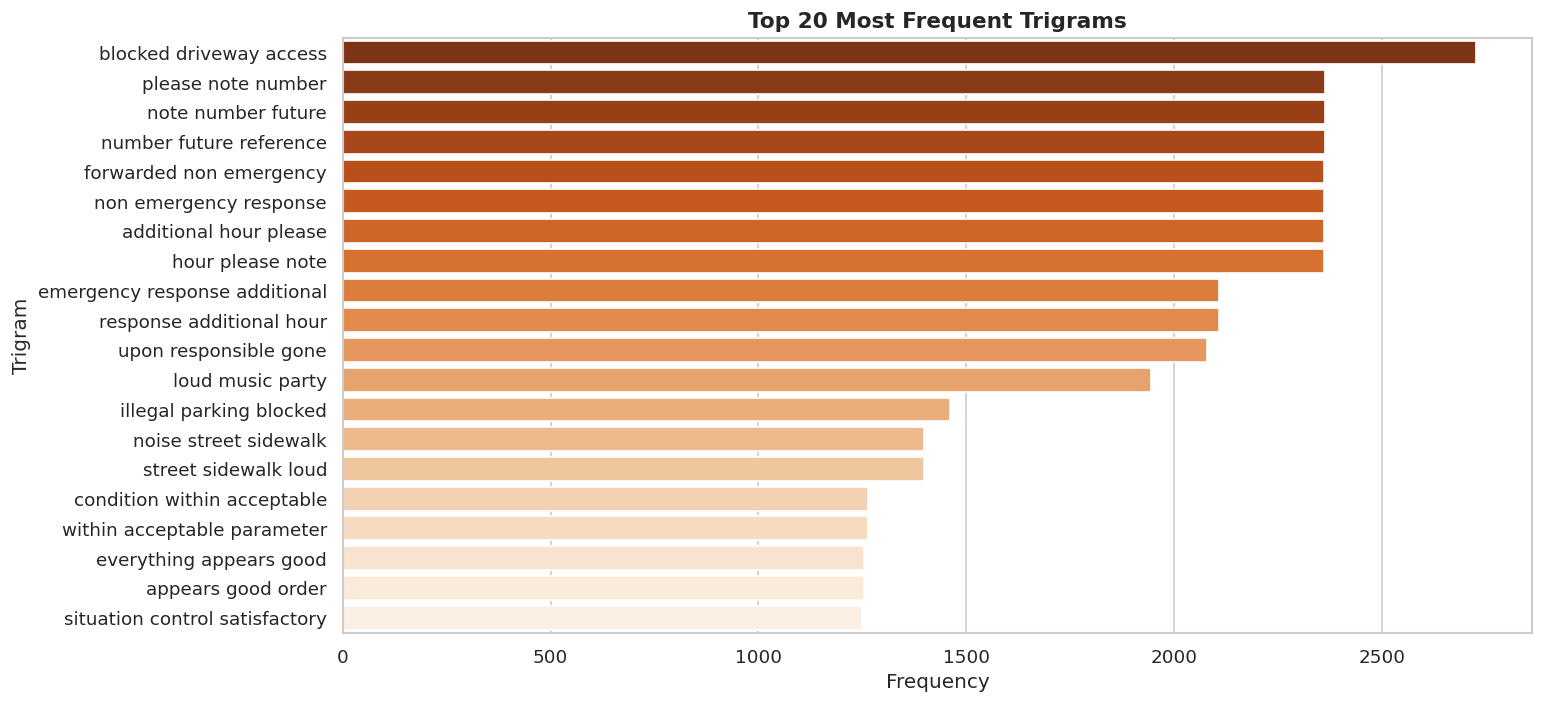

                         ngram  count
       blocked driveway access   2726
            please note number   2363
            note number future   2363
       number future reference   2363
       forwarded non emergency   2362
        non emergency response   2362
        additional hour please   2362
              hour please note   2362
 emergency response additional   2109
      response additional hour   2109
         upon responsible gone   2080
              loud music party   1944
       illegal parking blocked   1462
         noise street sidewalk   1398
          street sidewalk loud   1398
   condition within acceptable   1264
   within acceptable parameter   1264
       everything appears good   1255
            appears good order   1255
situation control satisfactory   1248


In [14]:
trigrams = get_ngram_freq(df['clean_text'], n=3, top_k=20)

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=trigrams, y='ngram', x='count', palette='Oranges_r', ax=ax)
ax.set_title('Top 20 Most Frequent Trigrams', fontsize=13, fontweight='bold')
ax.set_xlabel('Frequency')
ax.set_ylabel('Trigram')
plt.tight_layout()
save_plot('plot_09_trigrams.png')
plt.show()

print(trigrams.to_string(index=False))

## Bigrams per Top-4 Category (Side by Side)

💾 Saved → ../outputs/plot_10_bigrams_per_category.png


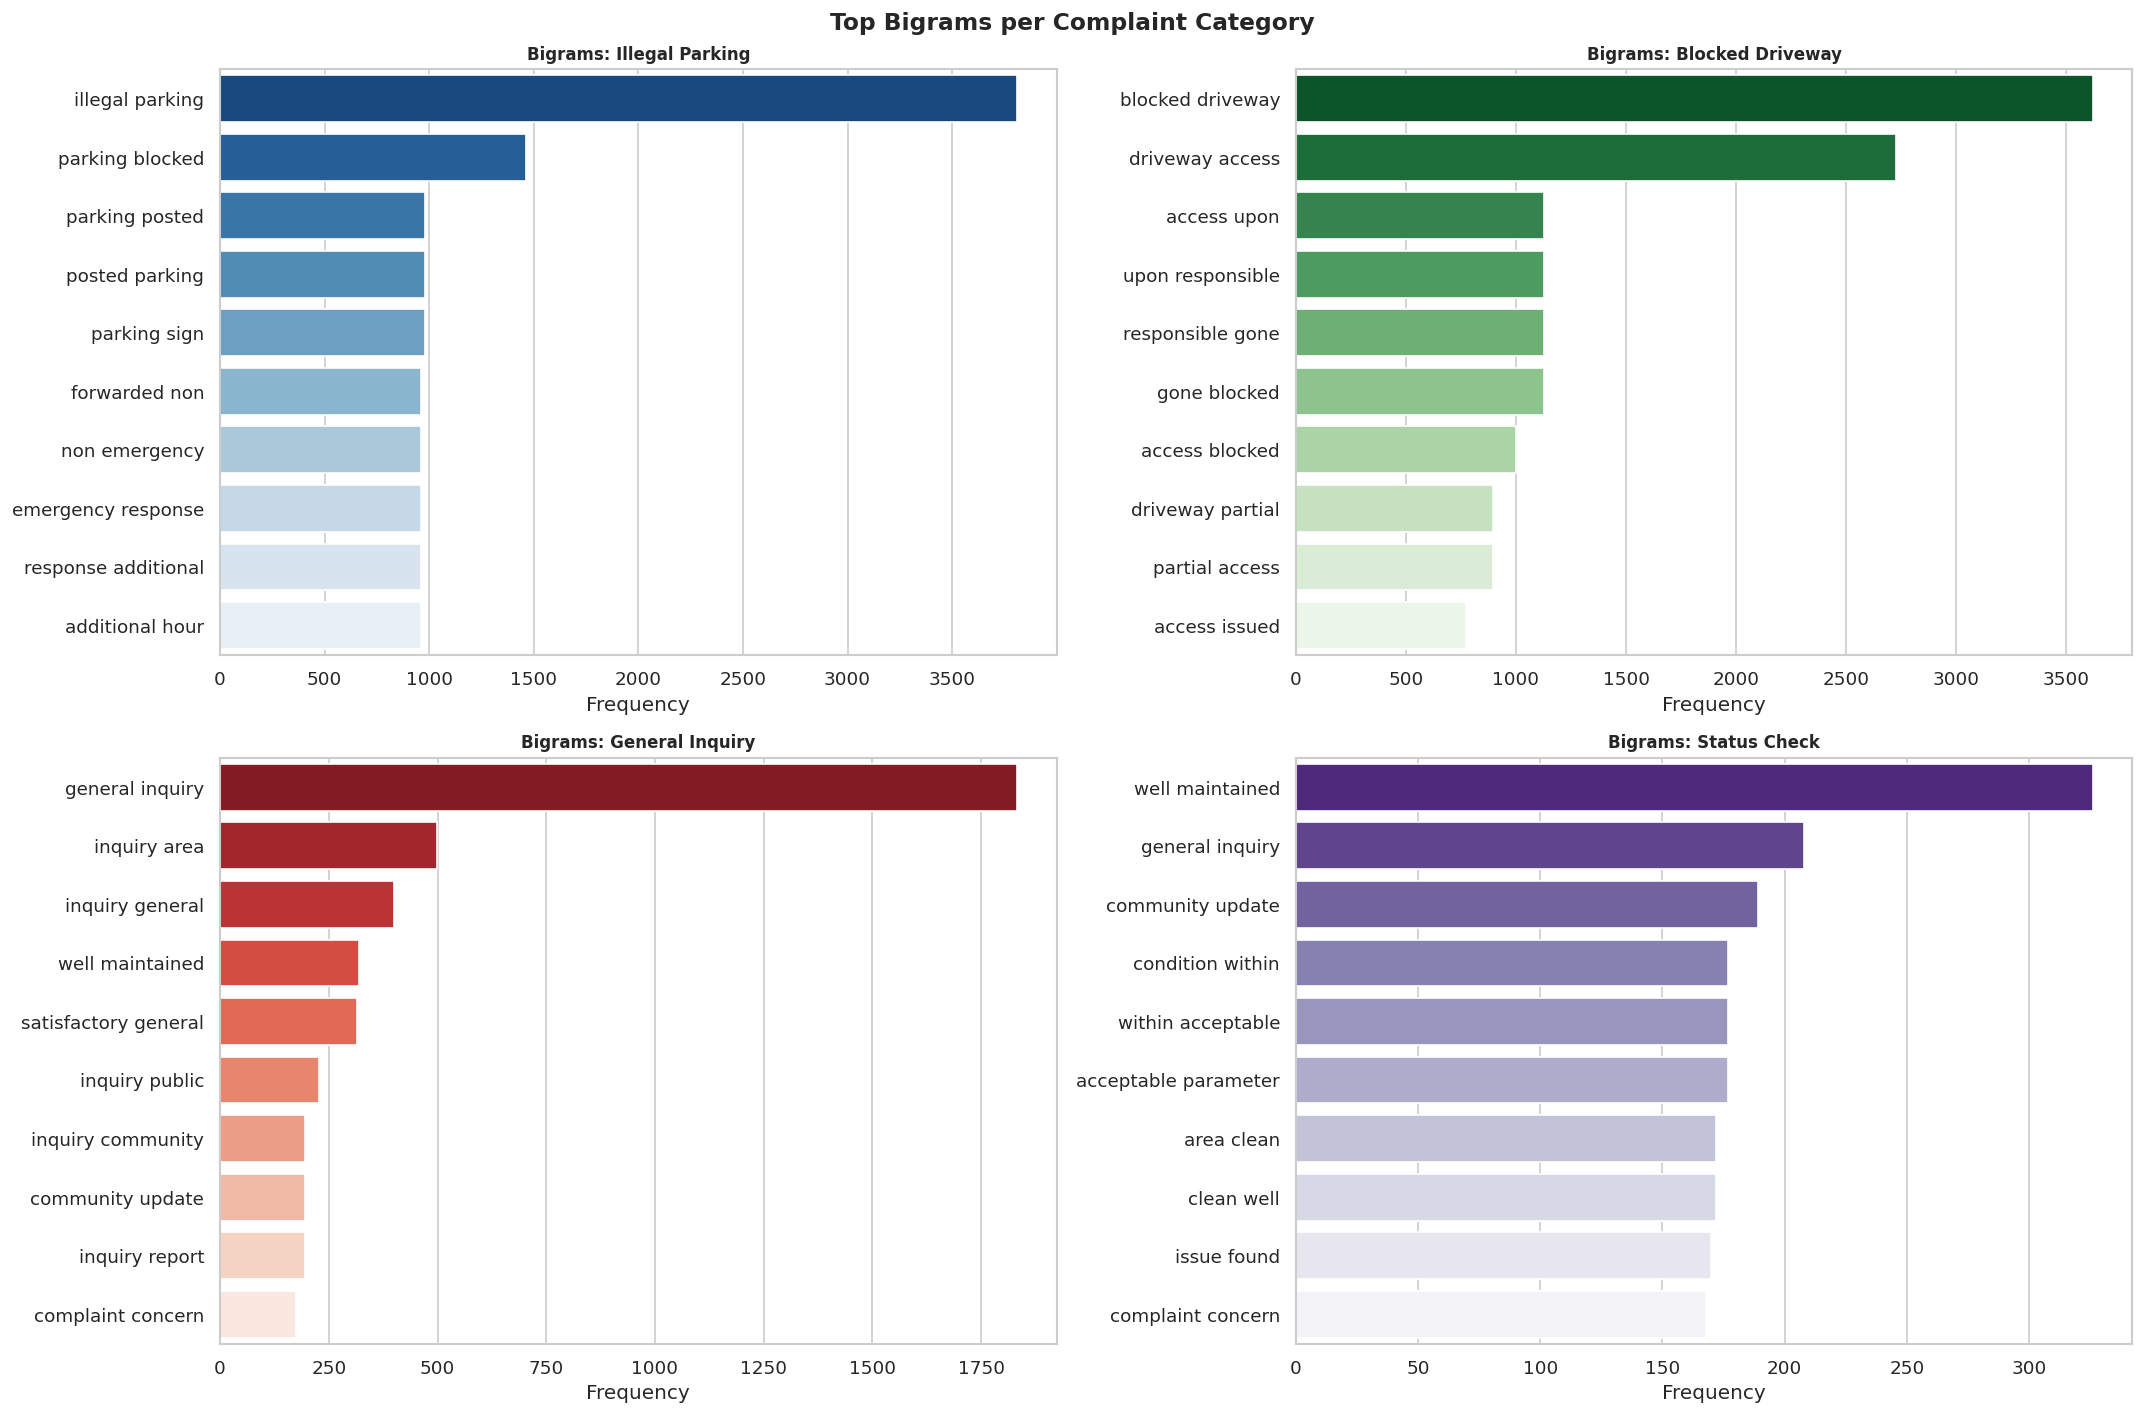

In [15]:
top4   = df['Complaint Type'].value_counts().head(4).index.tolist()
colors = ['Blues_r', 'Greens_r', 'Reds_r', 'Purples_r']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for ax, cat, color in zip(axes.flatten(), top4, colors):
    sub = df.loc[df['Complaint Type'] == cat, 'clean_text']
    bg  = get_ngram_freq(sub, n=2, top_k=10)
    if not bg.empty:
        sns.barplot(data=bg, y='ngram', x='count', palette=color, ax=ax)
    ax.set_title(f'Bigrams: {cat}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Frequency')
    ax.set_ylabel('')

plt.suptitle('Top Bigrams per Complaint Category', fontsize=14, fontweight='bold')
plt.tight_layout()
save_plot('plot_10_bigrams_per_category.png')
plt.show()

---
##  Final Summary: Check All Output Files

In [16]:
print('=' * 60)
print('        WEEK 1 COMPLETE — ALL FILES GENERATED')
print('=' * 60)

files = [
    ('plot_01_complaint_types.png',       'Top 15 complaint types bar chart'),
    ('plot_02_class_imbalance.png',       'Class distribution pie chart'),
    ('plot_03_borough.png',               'Borough complaint volume'),
    ('plot_04_hourly.png',                'Hourly complaint pattern'),
    ('plot_05_resolution_time.png',       'Resolution time histogram + boxplot'),
    ('plot_06_heatmap.png',               'Borough x Complaint heatmap'),
    ('wordcloud_01_all.png',              'Word cloud — all complaints'),
    ('wordcloud_02_per_category.png',     'Word clouds — per category'),
    ('plot_07_unigrams.png',              'Top 20 unigrams'),
    ('plot_08_bigrams.png',               'Top 20 bigrams'),
    ('plot_09_trigrams.png',              'Top 20 trigrams'),
    ('plot_10_bigrams_per_category.png',  'Bigrams per top-4 category'),
]

all_ok = True
for fname, desc in files:
    full_path = OUTPUT_DIR + fname
    exists    = '✅' if os.path.exists(full_path) else '❌ MISSING'
    if '❌' in exists:
        all_ok = False
    print(f'{exists}  {fname:<45} {desc}')

print()
if all_ok:
    print('🎉 All files present! Week 1 is complete.')
else:
    print('⚠️  Some files are missing. Re-run the cells marked ❌.')

        WEEK 1 COMPLETE — ALL FILES GENERATED
✅  plot_01_complaint_types.png                   Top 15 complaint types bar chart
✅  plot_02_class_imbalance.png                   Class distribution pie chart
✅  plot_03_borough.png                           Borough complaint volume
✅  plot_04_hourly.png                            Hourly complaint pattern
✅  plot_05_resolution_time.png                   Resolution time histogram + boxplot
✅  plot_06_heatmap.png                           Borough x Complaint heatmap
✅  wordcloud_01_all.png                          Word cloud — all complaints
✅  wordcloud_02_per_category.png                 Word clouds — per category
✅  plot_07_unigrams.png                          Top 20 unigrams
✅  plot_08_bigrams.png                           Top 20 bigrams
✅  plot_09_trigrams.png                          Top 20 trigrams
✅  plot_10_bigrams_per_category.png              Bigrams per top-4 category

🎉 All files present! Week 1 is complete.
